In [40]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
import json

NanoAODSchema.warn_missing_crossrefs = False

In [41]:
fileset = {
    'BulkGravToWW_1000': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-1000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/100000/D4404DCB-FBF8-C640-87B0-2DA1D5139083.root': "Events",
        },
        'metadata': {
            'is_mc': 'Events',
        },
    },
    'BulkGravToWW_2000': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-2000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/110000/0392B16C-94D0-CA41-A63B-BA1D6D30DE46.root': "Events",
        },
        'metadata': {
            'is_mc': 'Events',
        },
    }
}

In [42]:
test_dataset = 'BulkGravToWW_1000'
events = NanoEventsFactory.from_root(
    fileset[test_dataset]['files'],
    entry_stop = 10000,
    metadata = fileset[test_dataset]['metadata'],
    schemaclass = NanoAODSchema,
    delayed=False,
).events()



### Selecting interesting events

We will need to discuss what does it mean. For instance it could be events where both W decay to quarks to enhance our NN training sample, events where one W decays to leptons and one to quarks that more similar to what we will have in our final analysis. One could also select events where both Ws decay to leptons to compare with previous studies...

### TASK 1:
Lets refresh what is insiede an event

In [4]:
events.fields

['luminosityBlock',
 'genWeight',
 'LHE',
 'SoftActivityJetHT5',
 'GenDressedLepton',
 'PSWeight',
 'run',
 'RawMET',
 'FsrPhoton',
 'fixedGridRhoFastjetAll',
 'btagWeight',
 'fixedGridRhoFastjetCentral',
 'FatJet',
 'Pileup',
 'GenIsolatedPhoton',
 'LHEPdfWeight',
 'ChsMET',
 'GenPart',
 'LHEWeight',
 'SoftActivityJetHT10',
 'Generator',
 'GenJetAK8',
 'fixedGridRhoFastjetCentralNeutral',
 'SubGenJetAK8',
 'SoftActivityJetNjets10',
 'SoftActivityJetNjets2',
 'GenMET',
 'TkMET',
 'SubJet',
 'Tau',
 'LHEReweightingWeight',
 'SV',
 'RawPuppiMET',
 'TrigObj',
 'LHEPart',
 'fixedGridRhoFastjetCentralCalo',
 'SoftActivityJetHT',
 'SoftActivityJetNjets5',
 'HLTriggerFirstPath',
 'Photon',
 'genTtbarId',
 'OtherPV',
 'event',
 'L1',
 'Flag',
 'HTXS',
 'L1PreFiringWeight',
 'SoftActivityJet',
 'PuppiMET',
 'fixedGridRhoFastjetCentralChargedPileUp',
 'MET',
 'PV',
 'IsoTrack',
 'GenVisTau',
 'Muon',
 'HLT',
 'SoftActivityJetHT2',
 'LHEScaleWeight',
 'CaloMET',
 'HLTriggerFinalPath',
 'GenJet',


### TASK 2:

You should already be familiar with some of the fields but you can try to understand more here https://cms-nanoaod-integration.web.cern.ch/.

The link above is very technical and used by experienced analyzers so I do not expect you to learn or understand everything in it (I also do not know all!!)

### TASK 3:

Let's apply basic selections on Muons and Electrons. Understand what the selections mean. You can have a better idea of their effect if you plot some variables as the pt or if you print the number of electrons/muons in the event. Or how many events are passing the selections.

2547 out of 6848 muons pass the tight selection


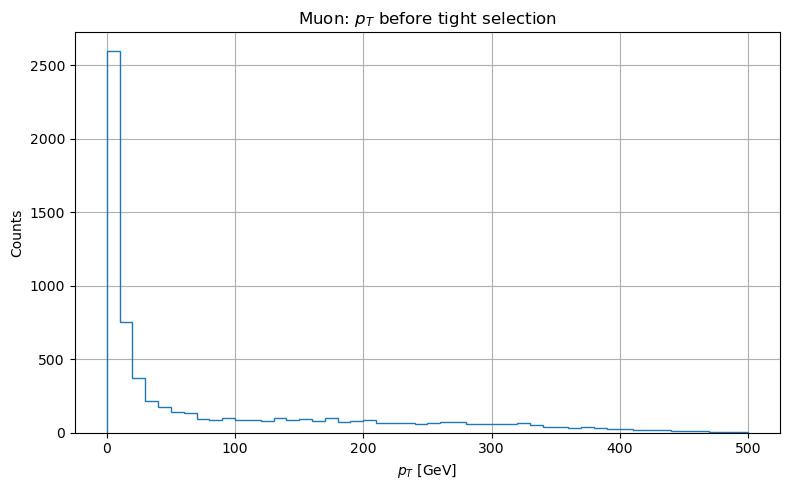

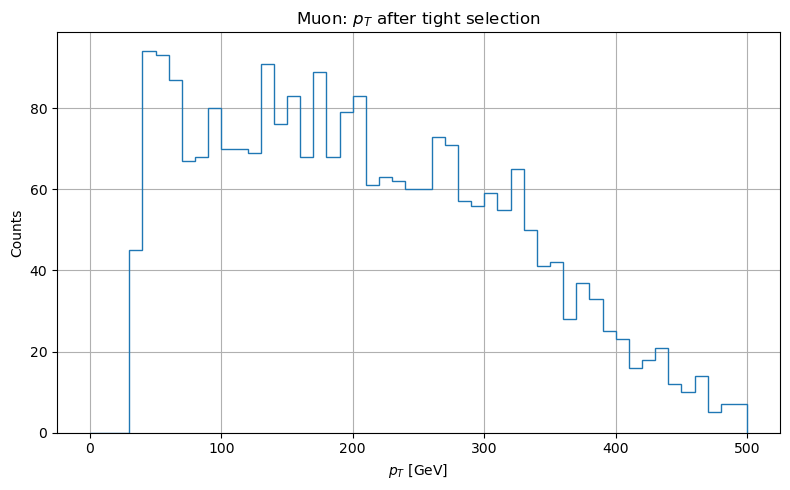

In [5]:
muons = events.Muon
electrons = events.Electron

# Muon Tight selection
muons_tight = muons[
    (muons.pt > 35) &
    (muons.eta < 2.4) &
    (muons.tightId) &
    (
        ((muons.pt < 10) & (muons.dxy < 0.01)) |
        ((muons.pt >= 10) & (muons.dxy < 0.02))
    ) &
    (muons.dz < 0.05) # &
    # particle flow isolated: tight or greater
    # (muons.pfIsoId >= 4)
]

print(len(ak.flatten(muons_tight)), 'out of' ,len(ak.flatten(muons)), 'muons pass the tight selection')

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), histtype='step')
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Muon: $p_T$ before tight selection")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(muons_tight.pt)), bins=50, range=(0, 500), histtype='step')
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Muon: $p_T$ after tight selection")
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 4:

Try to add similar selections for the electrons as well



2350 out of 8876 electrons pass the tight selection


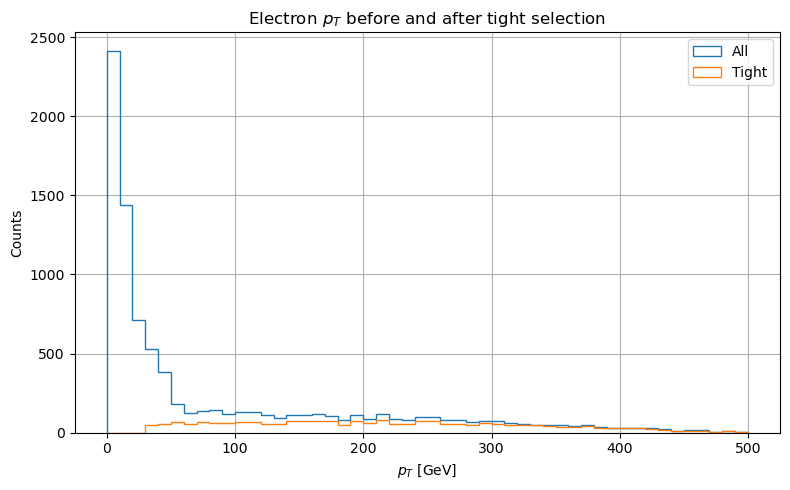

In [6]:
# Electron Tight selection

electrons_tight = electrons[
    (electrons.pt > 30) &
    (electrons.eta < 2.4) &  # barrel + endcap
    # (electrons.mvaFall17V2Iso_WP90 == True) &
    (
        ((electrons.pt < 15) & (electrons.dxy < 0.01)) |
        ((electrons.pt >= 15) & (electrons.dxy < 0.02))
    ) &
    # (electrons.cutBased >= 1) &      # tight cut-based ID
    (electrons.dxy < 0.05) & # dxy tighter
    (electrons.dz < 0.05) &
    (electrons.pfRelIso03_all < 0.15) &  # isolated
    (electrons.lostHits <= 1) &
    (electrons.convVeto == True)
]

print(len(ak.flatten(electrons_tight)), 'out of' ,len(ak.flatten(electrons)), 'electrons pass the tight selection')

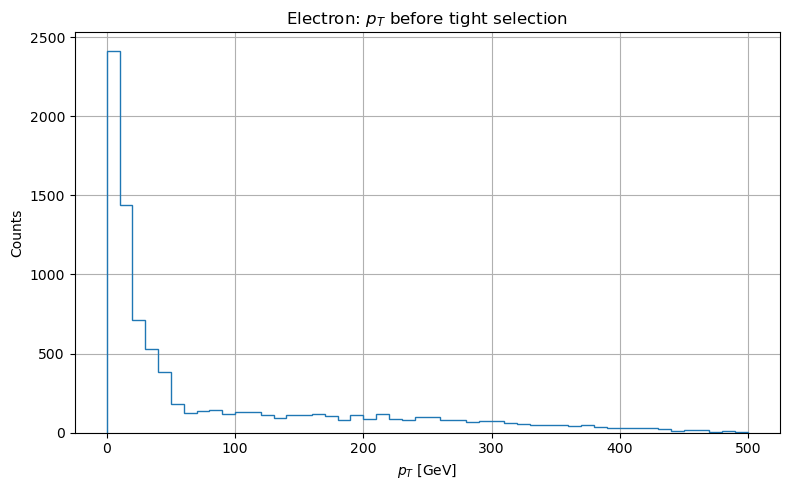

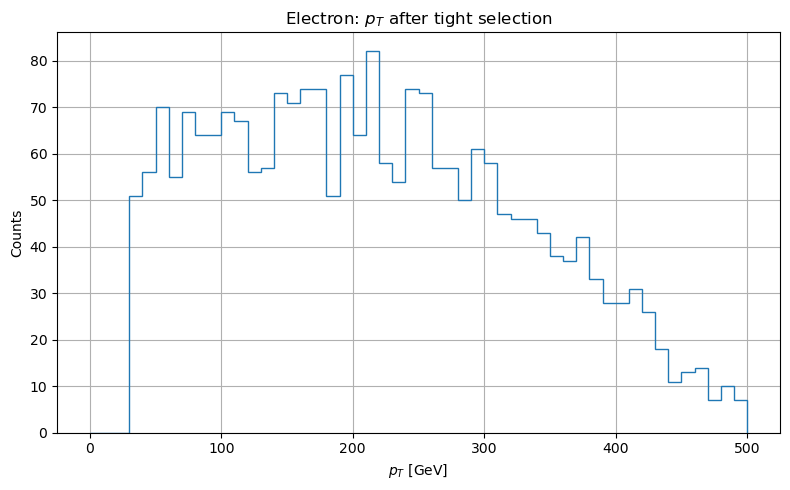

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), histtype='step')
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Electron: $p_T$ before tight selection")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(electrons_tight.pt)), bins=50, range=(0, 500), histtype='step')
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Electron: $p_T$ after tight selection")
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 5: 

Now require to have exactly one tightly identified electron or muon
and apply the following thresholds
```
electron_pt_threshold = 35
muon_pt_threshold = 30
pt_miss_threshold = 30
```

In [8]:
# Count of tight leptons
tight_muon_count = ak.num(muons_tight)
tight_electron_count = ak.num(electrons_tight)

# --- Loose leptons for vetoing ---
loose_muons = muons[muons.looseId]
loose_muons = loose_muons[loose_muons.pt > 10]

loose_electrons = electrons[electrons.cutBased >= 2]
loose_electrons = loose_electrons[loose_electrons.pt > 10]

# Count of loose leptons
loose_lepton_count = ak.num(loose_muons) + ak.num(loose_electrons)

# --- Event selection mask: exactly one tight lepton and no extra loose leptons ---
single_lepton_mask = ((tight_muon_count + tight_electron_count) == 1) & (loose_lepton_count == 1)

# Apply mask to get final event selection
events_selected = events[single_lepton_mask]

print(f"{len(events_selected)} events passed the tight lepton selection and loose veto.")

3393 events passed the tight lepton selection and loose veto.


In [9]:
# Masks for exactly one tight lepton
one_tight_electron_mask = (tight_electron_count == 1) & (tight_muon_count == 0) & (loose_lepton_count == 1)
one_tight_muon_mask = (tight_muon_count == 1) & (tight_electron_count == 0) & (loose_lepton_count == 1)

# Apply masks to original tight collections
tight_electron_one = electrons_tight[one_tight_electron_mask]
tight_muon_one = muons_tight[one_tight_muon_mask]


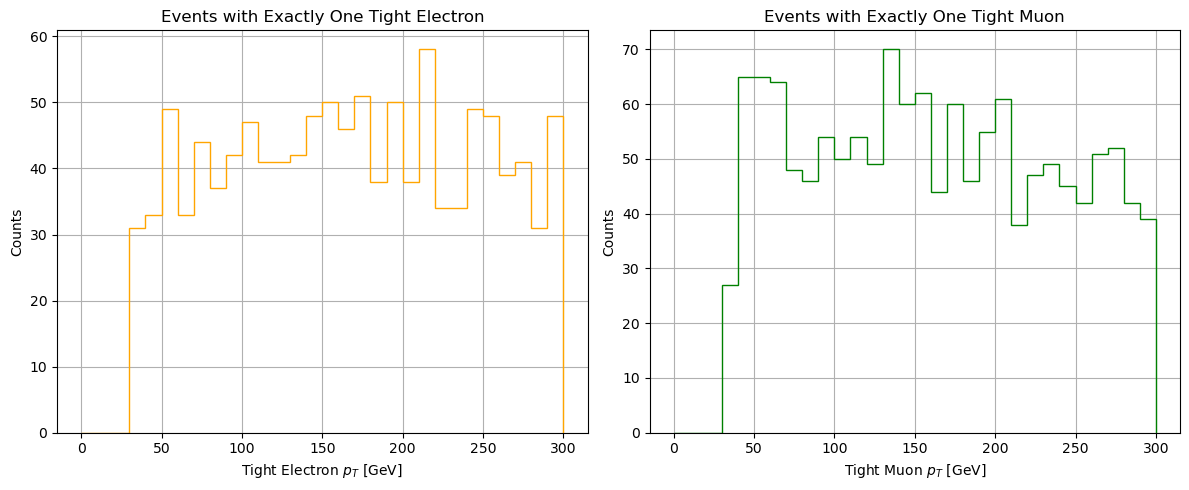

In [10]:
plt.figure(figsize=(12, 5))

# --- Electrons ---
plt.subplot(1, 2, 1)
plt.hist(ak.to_numpy(ak.flatten(tight_electron_one.pt)), bins=30, range=(0, 300), histtype='step', color='orange')
plt.xlabel(r"Tight Electron $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Events with Exactly One Tight Electron")
plt.grid(True)

# --- Muons ---
plt.subplot(1, 2, 2)
plt.hist(ak.to_numpy(ak.flatten(tight_muon_one.pt)), bins=30, range=(0, 300), histtype='step', color='green')
plt.xlabel(r"Tight Muon $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Events with Exactly One Tight Muon")
plt.grid(True)

plt.tight_layout()
plt.show()

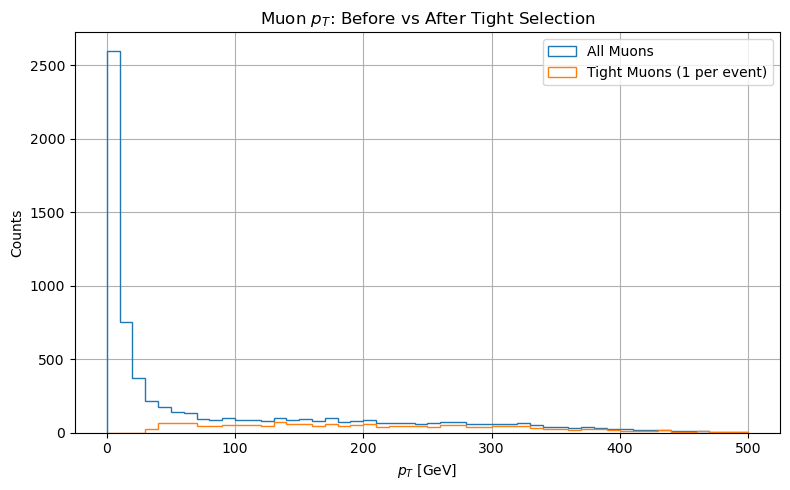

In [11]:
plt.figure(figsize=(8, 5))

# Before selection
plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), 
         histtype='step', label='All Muons')

# After tight selection and exactly one
plt.hist(ak.to_numpy(ak.flatten(tight_muon_one.pt)), bins=50, range=(0, 500), 
         histtype='step', label='Tight Muons (1 per event)')

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Muon $p_T$: Before vs After Tight Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

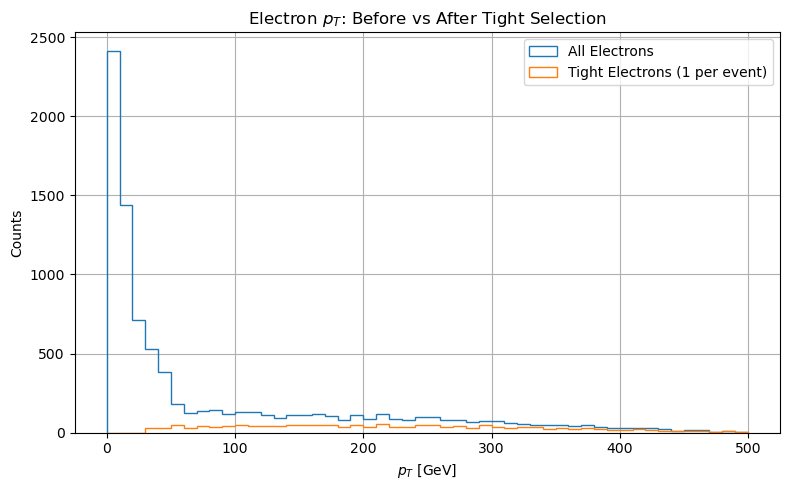

In [12]:
plt.figure(figsize=(8, 5))

# Before selection
plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), 
         histtype='step', label='All Electrons')

# After tight selection and exactly one
plt.hist(ak.to_numpy(ak.flatten(tight_electron_one.pt)), bins=50, range=(0, 500), 
         histtype='step', label='Tight Electrons (1 per event)')

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Electron $p_T$: Before vs After Tight Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# # Here are also some looser selections 
# # You can play plotting variables for tight and loose identified leptons, 
# # but it is not required...... 
# loose_muons = muons[muons.looseId]
# loose_muon_count = ak.num(loose_muons[loose_muons.pt > 10])

# loose_electrons = electrons[(electrons.cutBased >= 2)]
# loose_electron_count = ak.num(loose_electrons[loose_electrons.pt > 10])

# # Mask for vetoing extra loose leptons
# loose_lepton_veto_mask = (loose_muon_count + loose_electron_count) == 1

## We are mostly interested in Jets! 

### TASK 6:

Check the selections applied below on the jets. As before it is useful to plot some distributions like the jet mass or the momentum before and after applying the selections to check their effect and see how many events or jets pass a certain selection.

In [14]:
# FatJets cuts
clean_fatJets = events.FatJet[(events.FatJet.pt > 100) & (events.FatJet.eta < 2.4)]

#Jets cuts
clean_Jets = events.Jet[(events.Jet.pt > 30) & (events.Jet.eta < 4.6)]

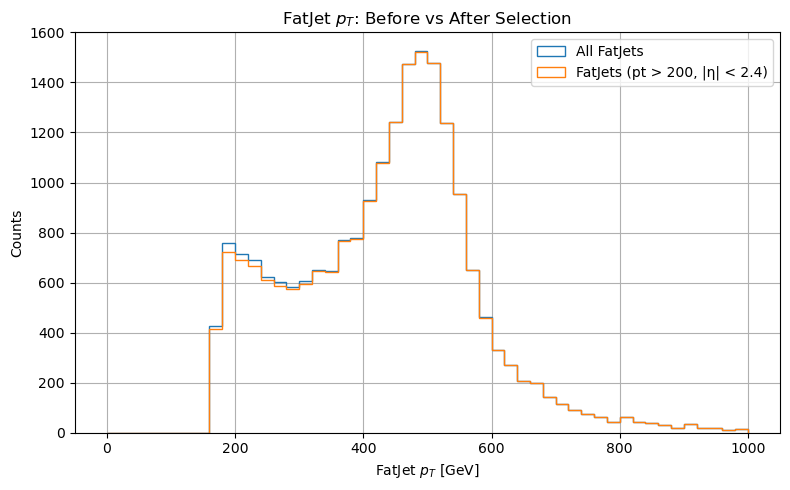

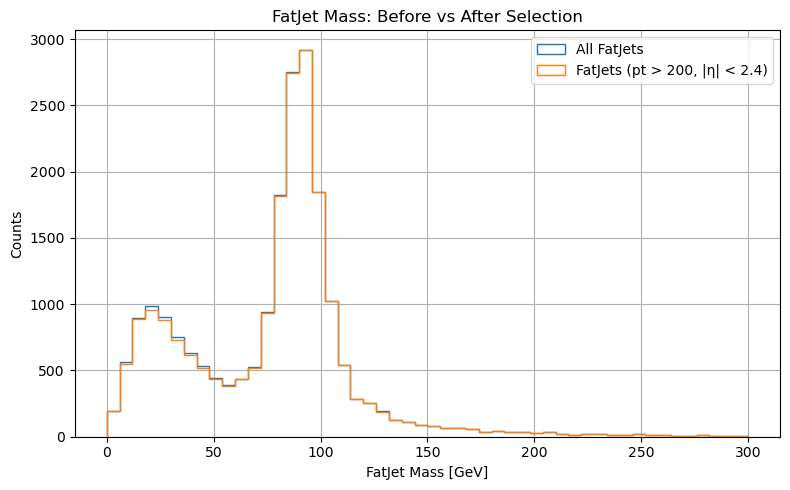

In [15]:
# --- FatJet pT ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.FatJet.pt)), bins=50, range=(0, 1000),
         histtype='step', label='All FatJets')
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.pt)), bins=50, range=(0, 1000),
         histtype='step', label='FatJets (pt > 200, |η| < 2.4)')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("FatJet $p_T$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- FatJet mass ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.FatJet.mass)), bins=50, range=(0, 300),
         histtype='step', label='All FatJets')
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.mass)), bins=50, range=(0, 300),
         histtype='step', label='FatJets (pt > 200, |η| < 2.4)')
plt.xlabel(r"FatJet Mass [GeV]")
plt.ylabel("Counts")
plt.title("FatJet Mass: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_177/271101519.py:23: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Jet $\eta$: Before vs After Selection")


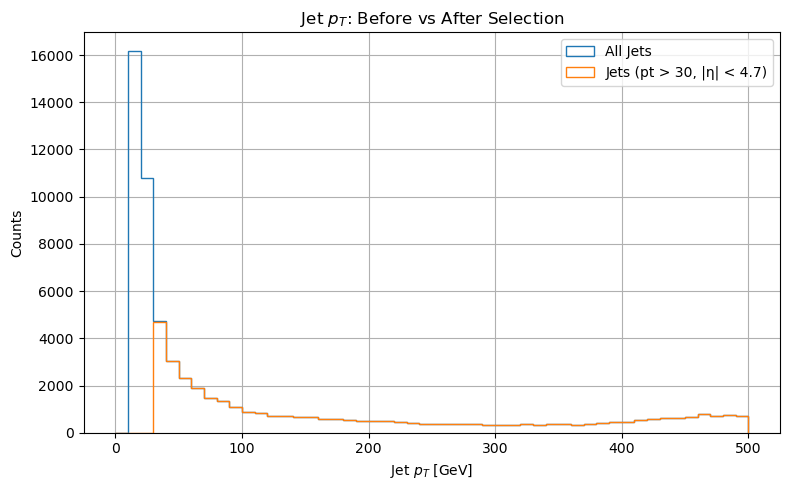

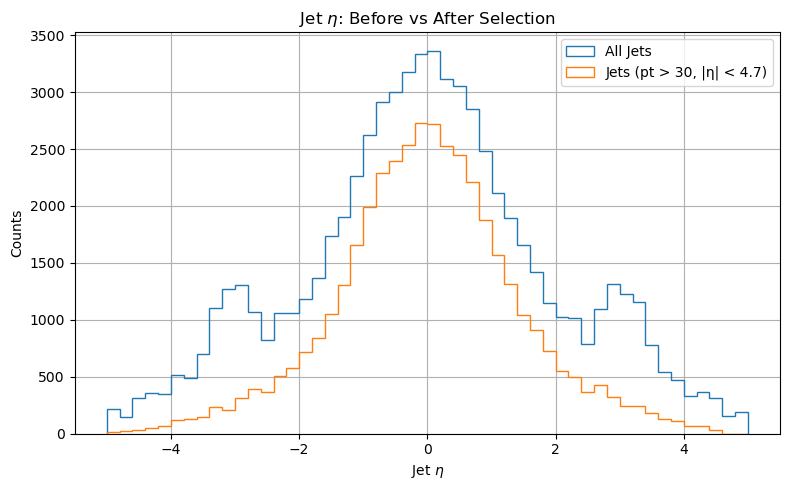

In [16]:
# --- Jet pT ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.Jet.pt)), bins=50, range=(0, 500),
         histtype='step', label='All Jets')
plt.hist(ak.to_numpy(ak.flatten(clean_Jets.pt)), bins=50, range=(0, 500),
         histtype='step', label='Jets (pt > 30, |η| < 4.7)')
plt.xlabel(r"Jet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Jet $p_T$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Jet eta ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.Jet.eta)), bins=50, range=(-5, 5),
         histtype='step', label='All Jets')
plt.hist(ak.to_numpy(ak.flatten(clean_Jets.eta)), bins=50, range=(-5, 5),
         histtype='step', label='Jets (pt > 30, |η| < 4.7)')
plt.xlabel(r"Jet $\eta$")
plt.ylabel("Counts")
plt.title("Jet $\eta$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 7:

To avoid double counting we need to remove Jets overlapping with FatJets. Check how this is done below.

In [17]:
#Removing AK4(Jet) jets overlapping with AK8(FatJets) jets
# Get all combinations of jets and fatjets in every event
#--- Step 1: Form all possible Jet–FatJet pairs per event
jets_fatjets = ak.cartesian({"x": clean_Jets, "y": clean_fatJets})
# Check that jets satisfy the isolation 
# --- Step 2: Compute ΔR² separation between each Jet–FatJet pair
jets_iso_f = ((jets_fatjets["x"].eta-jets_fatjets["y"].eta)**2+(jets_fatjets["x"].phi-jets_fatjets["y"].phi)**2>0.8**2)
# Mask the jets_fatjets with the jets_iso_f to get jets isolated from fatjets
# --- Step 3: Mask out jets with ΔR < 0.8 (i.e. remove overlapping jets)
jets_fatjets = jets_fatjets[jets_iso_f]
# Separate pairs into jets and fatjets, redefining the jets (but not the fatjets) 
# --- Step 4: Unpack the surviving jets (no need to redefine the fatjets)
jets, fj = ak.unzip(jets_fatjets)

### TASK 8:

1) Can you add below the initial FatJet pt distribution? and see how it is changed after applying all selections
2) Can you plot the second leading jet?

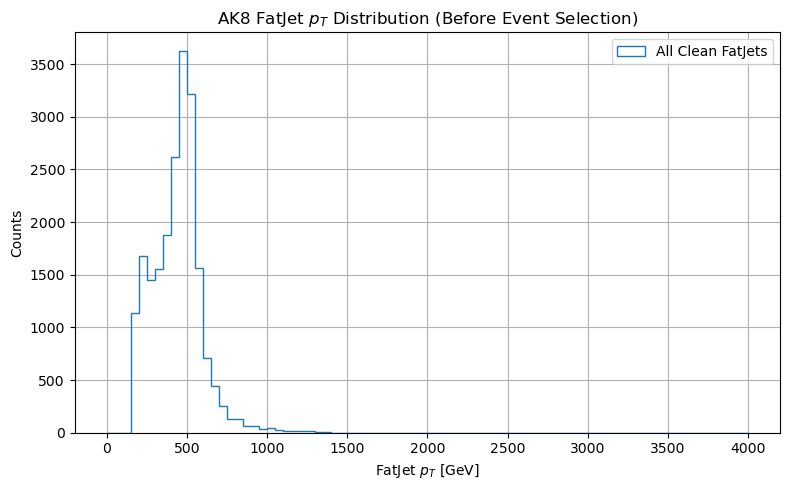

In [18]:
# Plot distribution of AK8 FatJets before applying AK8jets_candidates_mask
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.pt)), bins=80, range=(0, 4000),
         histtype='step', label='All Clean FatJets')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("AK8 FatJet $p_T$ Distribution (Before Event Selection)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fb93c5683e0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

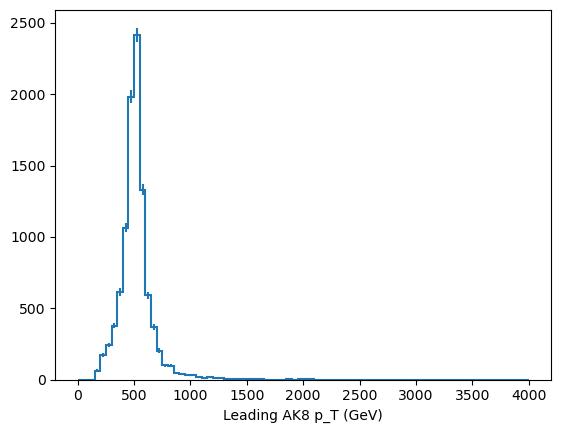

In [19]:
AK8jets_candidates_mask = ak.num(clean_fatJets) >= 1
Wjets_candidates = clean_fatJets[AK8jets_candidates_mask]

leading_W_jet = Wjets_candidates[:, 0]
leading_W_jet_pt = leading_W_jet.pt

leading_W_pt_hist = hist.Hist(hist.axis.StrCategory(name='dataset', label="Dataset", categories=[], growth=True),
                            hist.axis.Regular(name='leading_AK8_pt', label='Leading AK8 p_T (GeV)', bins=80, start=0, stop=4000))
leading_W_pt_hist.fill(dataset=test_dataset, leading_AK8_pt=leading_W_jet_pt)
leading_W_pt_hist.plot1d()

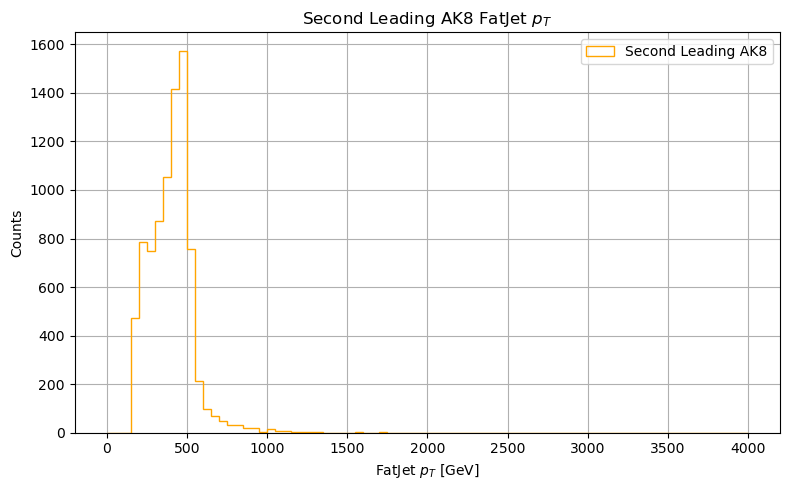

In [20]:
# Require events with at least two clean AK8 FatJets
AK8jets_2_mask = ak.num(clean_fatJets) >= 2
Wjets_2_candidates = clean_fatJets[AK8jets_2_mask]

# Second-leading jet: index 1
second_W_jet = Wjets_2_candidates[:, 1]
second_W_jet_pt = second_W_jet.pt

# Plot second-leading AK8 jet
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(second_W_jet_pt), bins=80, range=(0, 4000),
         histtype='step', color='orange', label='Second Leading AK8')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Second Leading AK8 FatJet $p_T$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

### Exploratory aside on the difference in kinemetic variables from jets in fully-hadronic and semi-leptonic W decay channels

### Goal: Compare the leading and sub leading jet from the fuly hadronic vs the leading jet from the semi-leptonic W decay channels

Steps:
1. Classify Events:
    - semi-leptonic mask: events with exactly 1 tight muon or electron and 1 AK8 jet
    - fully hadronic mask: events 0 tight leptons and 2 AK8 jets
2. Extract Leading Jets:
   - semi leptonic jets: FatJet in semi-leptonic events.
   - hadronic jets: Leading FatJet in hadronic events.
   - hadronic jets: Subleading FatJet
3. Plot Comparisons:
   - Overlay histograms of pt and eta for types of events (maybe softdrop mass too).

In [21]:
# define tight lepton masks (already defined these earlier in the notebook)
n_tight_muons = ak.num(muons_tight)
n_tight_electrons = ak.num(electrons_tight)

# event masks
semi_leptonic_mask = (
    ((n_tight_muons == 1) & (n_tight_electrons == 0)) |
    ((n_tight_muons == 0) & (n_tight_electrons == 1))) & (ak.num(clean_fatJets) >= 1)

fully_hadronic_mask = (
    (n_tight_muons == 0) & (n_tight_electrons == 0) &
    (ak.num(clean_fatJets) >= 2))

In [22]:
# semi-leptonic W decay: 
semi_leptonic_fatjets = clean_fatJets[semi_leptonic_mask]
# fully hadronic W decay: 
fully_hadronic_fatjets = clean_fatJets[fully_hadronic_mask]

In [23]:
# For plotting (flatten to leading/subleading jets)
semi_leptonic_leading_jet = semi_leptonic_fatjets[:, 0]
fully_hadronic_leading_jet = fully_hadronic_fatjets[:, 0]
# assumes there are at least two AK8 jets in the event
fully_hadronic_second_jet = fully_hadronic_fatjets[:, 1]

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_177/1595728449.py:4: SyntaxWarning: invalid escape sequence '\e'
  "eta": ("Jet $\eta$", (-3, 3), lambda jet: jet.eta),


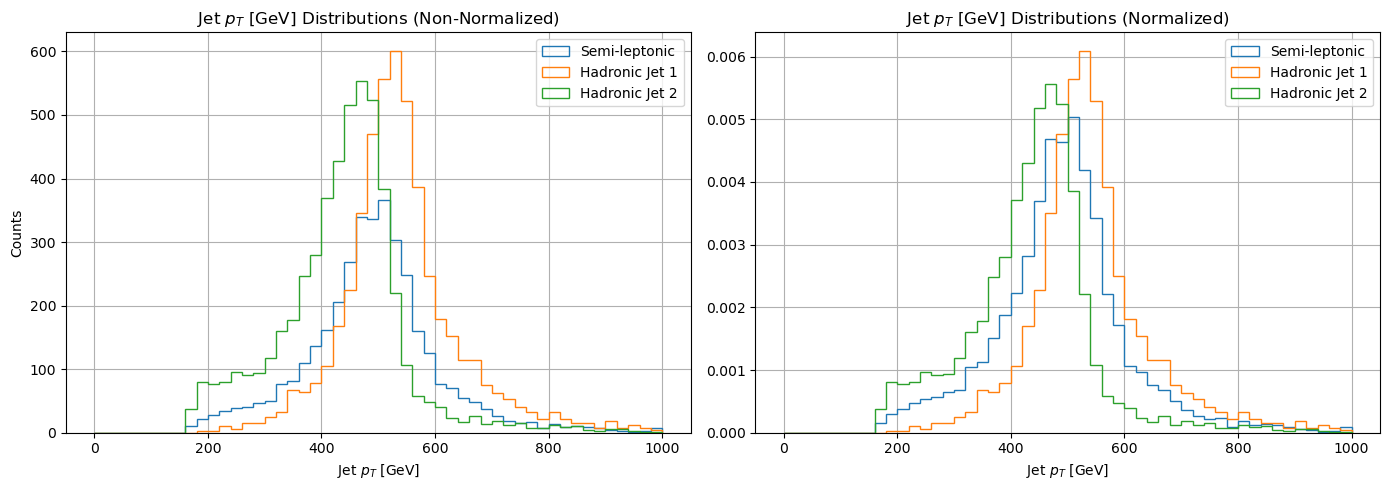

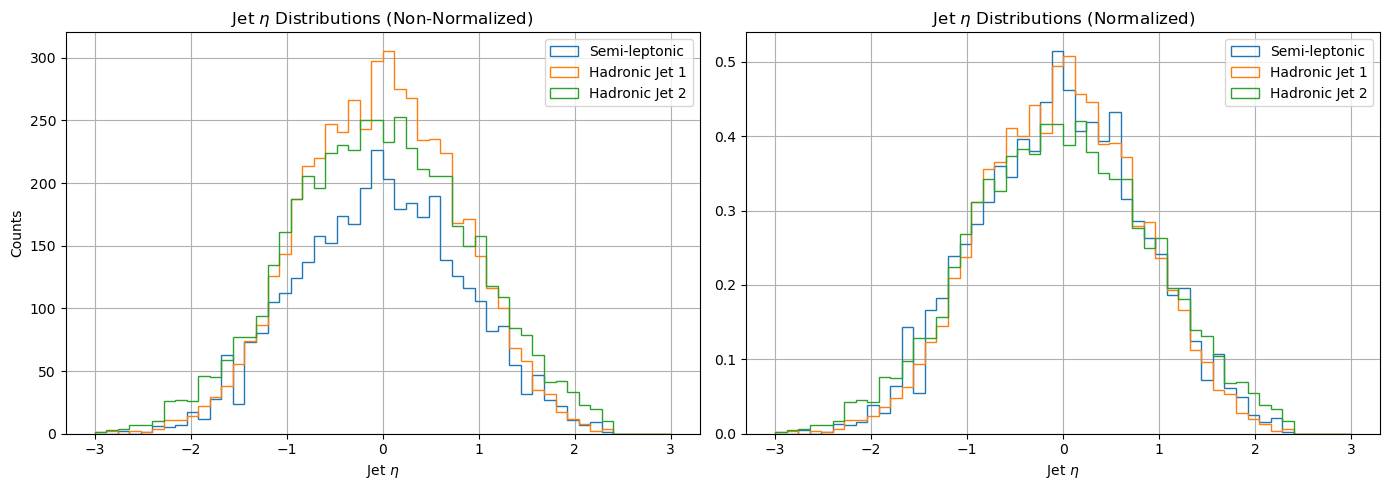

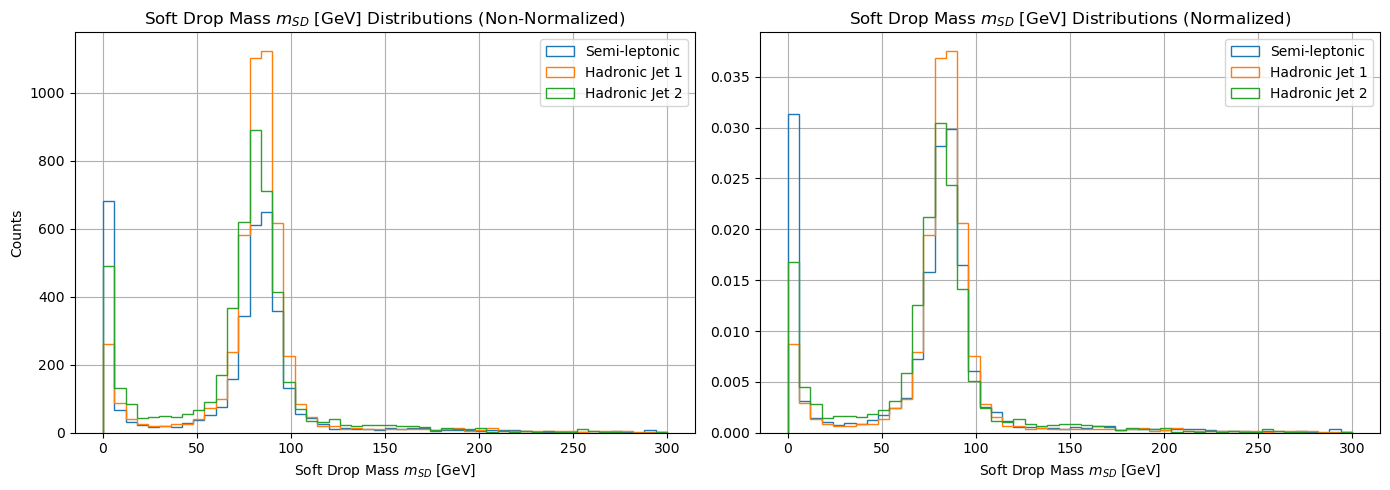

In [24]:
# dict mapping jet properties to axis labels, plot ranges, and access functions
jet_sets = {
    "pt": ("Jet $p_T$ [GeV]", (0, 1000), lambda jet: jet.pt),
    "eta": ("Jet $\eta$", (-3, 3), lambda jet: jet.eta),
    "msoftdrop": ("Soft Drop Mass $m_{SD}$ [GeV]", (0, 300), lambda jet: jet.msoftdrop)
}
# loop over each jet parameter to generate plots
for key, (xlabel, rng, accessor) in jet_sets.items():
    plt.figure(figsize=(14, 5))
    
    # left: non-normalized
    plt.subplot(1, 2, 1)
    plt.hist(ak.to_numpy(accessor(semi_leptonic_leading_jet)), bins=50, range=rng,
             histtype='step', label='Semi-leptonic')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_leading_jet)), bins=50, range=rng,
             histtype='step', label='Hadronic Jet 1')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_second_jet)), bins=50, range=rng,
             histtype='step', label='Hadronic Jet 2')
    plt.title(f"{xlabel} Distributions (Non-Normalized)")
    plt.xlabel(xlabel)
    plt.ylabel("Counts")
    plt.legend()
    plt.grid(True)

    # right: normalized
    plt.subplot(1, 2, 2)
    plt.hist(ak.to_numpy(accessor(semi_leptonic_leading_jet)), bins=50, range=rng,
             density=True, histtype='step', label='Semi-leptonic')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_leading_jet)), bins=50, range=rng,
             density=True, histtype='step', label='Hadronic Jet 1')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_second_jet)), bins=50, range=rng,
             density=True, histtype='step', label='Hadronic Jet 2')
    plt.title(f"{xlabel} Distributions (Normalized)")
    plt.xlabel(xlabel)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# can probs remove the non-normalized plots, not important to keep

#### from slides: using msoftdrop instead of raw mass because:
- more stable against pileup and soft radiation.
- captures the mass of boosted W bosons decaying into jets.

#### cos$\theta$ * calculation for all three jets

In [25]:
# -- Subjet Pair Extraction for Semi-Leptonic Events --
def extract_semi_subjet_pairs(fatjets, all_subjets, category_name="Semi-Leptonic"):
    pairs = []
    n_skipped = 0

    for event_fjs, event_sjs in zip(fatjets, all_subjets):
        if len(event_fjs) == 0:
            continue
        fj = event_fjs[0]
        try:
            idx1, idx2 = fj.subJetIdx1, fj.subJetIdx2
            if idx1 < 0 or idx2 < 0:
                raise ValueError("Invalid subjet indices")

            sj1, sj2 = event_sjs[idx1], event_sjs[idx2]
            vec1 = vector.obj(pt=sj1["pt"], eta=sj1["eta"], phi=sj1["phi"], mass=sj1["mass"])
            vec2 = vector.obj(pt=sj2["pt"], eta=sj2["eta"], phi=sj2["phi"], mass=sj2["mass"])
            pairs.append((vec1, vec2))
        except (KeyError, TypeError, ValueError):
            n_skipped += 1

    print(f"[{category_name}] Valid subjet pairs: {len(pairs)}, Skipped: {n_skipped}")
    return pairs

# -- Subjet Pair Extraction for Hadronic Events --
def extract_had_subjet_pairs(fatjets, category_name="Hadronic"):
    valid_pairs = []
    n_skipped = 0

    for subjets in fatjets.subjets:
        if len(subjets) < 2:
            n_skipped += 1
            continue
        try:
            sj1, sj2 = subjets[0], subjets[1]
            vec1 = vector.obj(pt=sj1["pt"], eta=sj1["eta"], phi=sj1["phi"], mass=sj1["mass"])
            vec2 = vector.obj(pt=sj2["pt"], eta=sj2["eta"], phi=sj2["phi"], mass=sj2["mass"])
            valid_pairs.append((vec1, vec2))
        except (KeyError, TypeError, ValueError):
            n_skipped += 1

    print(f"[{category_name}] Valid subjet pairs: {len(valid_pairs)}, Skipped: {n_skipped}")
    return valid_pairs

In [26]:
# -- Extract Pairs from Each Jet Category --
semi_pairs = extract_semi_subjet_pairs(semi_leptonic_fatjets, events.SubJet[semi_leptonic_mask], "Semi-Leptonic")
had1_pairs = extract_had_subjet_pairs(fully_hadronic_leading_jet, "Hadronic Lead")
had2_pairs = extract_had_subjet_pairs(fully_hadronic_second_jet, "Hadronic Sublead")

[Semi-Leptonic] Valid subjet pairs: 3156, Skipped: 509
[Hadronic Lead] Valid subjet pairs: 4980, Skipped: 30
[Hadronic Sublead] Valid subjet pairs: 4780, Skipped: 230


In [31]:
# -- Compute cos(θ*) for Given Subjet Pairs --
def compute_cos_theta_star_from_vectors(subjet_pairs, category_name=""):
    cos_theta_star = []
    n_success = 0
    n_skipped = 0

    for i, (vec1, vec2) in enumerate(subjet_pairs):
        # 1) Reconstruct the W four-vector in the lab frame
        w_lab = vec1 + vec2
        if w_lab.mass < 1e-3 or w_lab.E <= 1e-6:
            n_skipped += 1

        # 2) Build the boost to the W rest frame
        beta3 = -w_lab.to_beta3()
        if beta3.mag < 1e-6:
            n_skipped += 1
            continue
        
        # 3) RAPIDITY SORT: pick the subjet that’s more “backward” in η
        #    (this ensures the dot can go negative when it should)
        if vec1.rapidity < vec2.rapidity:
            q = vec1  
        else:
            q = vec2

        # 4) Boost that chosen subjet into the W rest frame
        q_rest = q.boost_beta3(beta3)
        if q_rest.to_beta3().mag < 1e-6:
            n_skipped += 1
            continue

        # 5) Compute signed cosθ* via vector’s unit-vector dot        
        w_hat  = w_lab.to_beta3().unit()
        q_hat  = q_rest.to_beta3().unit()
        cos_theta = q_hat.dot(w_hat)

        cos_theta_star.append(cos_theta)
        n_success += 1

    print(f"[{category_name}] Computed cosθ* for {n_success} subjet pairs, Skipped: {n_skipped}")

    if len(cos_theta_star) > 0:
            cos_array = np.array(cos_theta_star)
            print(f"[{category_name}] cosθ* range: min = {cos_array.min():.3f}, max = {cos_array.max():.3f}")
            print(f"[{category_name}] Histogram counts (neg, zero, pos): "
                  f"{np.sum(cos_array < 0)}, {np.sum(cos_array == 0)}, {np.sum(cos_array > 0)}")
    
    return np.array(cos_theta_star)

In [32]:
# -- Compute cos(θ*) for Each Category --
cos_theta_semi = compute_cos_theta_star_from_vectors(semi_pairs, "Semi-Leptonic")
cos_theta_had1 = compute_cos_theta_star_from_vectors(had1_pairs, "Hadronic Lead")
cos_theta_had2 = compute_cos_theta_star_from_vectors(had2_pairs, "Hadronic Sublead")

[Semi-Leptonic] Computed cosθ* for 3156 subjet pairs, Skipped: 0
[Semi-Leptonic] cosθ* range: min = -0.867, max = 0.855
[Semi-Leptonic] Histogram counts (neg, zero, pos): 1574, 0, 1582
[Hadronic Lead] Computed cosθ* for 4980 subjet pairs, Skipped: 0
[Hadronic Lead] cosθ* range: min = -0.909, max = 0.873
[Hadronic Lead] Histogram counts (neg, zero, pos): 2459, 0, 2521
[Hadronic Sublead] Computed cosθ* for 4780 subjet pairs, Skipped: 0
[Hadronic Sublead] cosθ* range: min = -0.878, max = 0.931
[Hadronic Sublead] Histogram counts (neg, zero, pos): 2415, 0, 2365


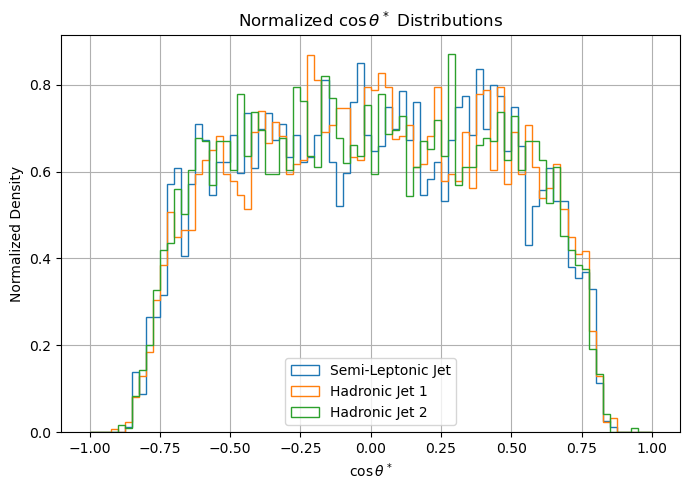

In [33]:
# -- Plot Normalized cos(θ*) Distributions --
plt.figure(figsize=(7, 5))
plt.hist(cos_theta_semi, bins=80, range=(-1, 1), density=True,
         histtype='step', label='Semi-Leptonic Jet')
plt.hist(cos_theta_had1, bins=80, range=(-1, 1), density=True,
         histtype='step', label='Hadronic Jet 1')
plt.hist(cos_theta_had2, bins=80, range=(-1, 1), density=True,
         histtype='step', label='Hadronic Jet 2')
plt.xlabel(r"$\cos\theta^*$")
plt.ylabel("Normalized Density")
plt.title(r"Normalized $\cos\theta^*$ Distributions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

*de-bugging blocks no longer needed*

In [33]:
# print("FatJets per semi-leptonic event:", ak.num(semi_leptonic_fatjets))
# print("Shape of semi_leptonic_fatjets:", ak.type(semi_leptonic_fatjets))
# for i in range(5):
#     print(f"Event {i} subJetIdx1:", semi_leptonic_fatjets[i].subJetIdx1)
#     print(f"Event {i} subJetIdx2:", semi_leptonic_fatjets[i].subJetIdx2)
# for i in range(5):
#     print(f"Event {i} has {len(events.SubJet[i])} subjets")

In [34]:
# print("Type/len of `semi_leptonic_fatjets`:", type(semi_leptonic_fatjets), len(semi_leptonic_fatjets))
# print("First few `.subJetIdx1` values:", semi_leptonic_fatjets.subJetIdx1[:10])
# print("First few `.subJetIdx2` values:", semi_leptonic_fatjets.subJetIdx2[:10])
# print("First few `subjets` counts per event:", [len(s) for s in events.SubJet[:10]])

In [32]:
# print("Type/len of `fully_hadronic_fatjets`:", type(fully_hadronic_fatjets), len(fully_hadronic_fatjets))
# print("First few `.subJetIdx1` values:", fully_hadronic_fatjets.subJetIdx1[:10])
# print("First few `.subJetIdx2` values:", fully_hadronic_fatjets.subJetIdx2[:10])
# print("First few `subjets` counts per event:", [len(s) for s in events.SubJet[:10]])

In [43]:
# sj1, sj2 = semi_pairs[0]
# print("sj1 type:", type(sj1))
# print("sj1 content:", sj1)
# print("sj1 fields:", sj1.fields if hasattr(sj1, "fields") else "No fields")

In [44]:
# for sj1, sj2 in semi_pairs[:5]:
#     print(f"sj1: pt={sj1.pt}, mass={sj1.mass} | sj2: pt={sj2.pt}, mass={sj2.mass}")

# for sj1, sj2 in had1_pairs[:5]:
#     print(f"sj1: pt={sj1.pt}, mass={sj1.mass} | sj2: pt={sj2.pt}, mass={sj2.mass}")

## Now that you are familiar with the physics behind what we are doing we move to the ML part


### TASK 9: 

To train the neural network it is useful to first select the interesting events (as we have done above). But now we need to save the events and variables in a more useful file format called h5. Check the example below to see how to add variables to be saved

In [35]:
# basic h5 creation
import pandas as pd
# Convert awkward array to numpy array (flat)
leading_W_jet_pt_np = ak.to_numpy(leading_W_jet_pt)
leading_W_jet_eta_np = ak.to_numpy(leading_W_jet.eta)
# Optional — wrap in a DataFrame for easy labeling
df_leading_W_jet_pt = pd.DataFrame({'leading_W_jet_pt': leading_W_jet_pt_np, 'leading_W_jet_eta': leading_W_jet_eta_np})

In [36]:
df_leading_W_jet_pt.to_hdf('leading_W_jet_pt.h5', key='df', mode='w')


In [37]:
# run this command to see if the file has been creatd
import os
os.listdir('.')

['leading_W_jet_pt.h5',
 'resonancesTest_plotVariables.ipynb',
 '.gitignore',
 'resonancesTest_selections_h5.ipynb',
 'leading_W_features.h5',
 'RSGravToWWToWlepWhad_M-1200.root',
 '.git',
 '.ipynb_checkpoints',
 'BulkGravitonToWW_M-1000.root',
 'README.md']

In [38]:
# now read the file to see if it looks ok
pd.read_hdf('leading_W_jet_pt.h5')

,leading_W_jet_pt,leading_W_jet_eta
0,348.75,0.429260
1,468.25,0.294067
2,497.50,-0.151031
3,606.50,0.087845
4,490.75,-0.167938
...,...,...
970,688.50,-0.026592
971,630.50,-0.421326
972,532.00,-1.101562
973,489.25,-0.752319


### TASK 10: 

Now we need to add variables that will be useful for our polarization tagger. So cos theta is one of them for sure! You can recall the calculations from the other notebook. 

Are there more variables we want to add? If nothing else comes up we can 
1) add the full stats!!
2) move to the ML part! 

In [39]:
# FatJet vector defined
fatjet_vec = vector.array({
    "pt": leading_W_jet.pt,
    "eta": leading_W_jet.eta,
    "phi": leading_W_jet.phi,
    "mass": leading_W_jet.mass,
})

In [40]:
# Extract variables from leading W candidate (FatJet)
df_features = pd.DataFrame({
    'pt': ak.to_numpy(leading_W_jet.pt),
    'eta': ak.to_numpy(leading_W_jet.eta),
    'mass': ak.to_numpy(leading_W_jet.mass),
    'msoftdrop': ak.to_numpy(leading_W_jet.msoftdrop),
})

# Save to h5 file
df_features.to_hdf('leading_W_features.h5', key='df', mode='w')

# Confirm it was saved
import os
print(os.listdir('.'))

['leading_W_jet_pt.h5', 'resonancesTest_plotVariables.ipynb', '.gitignore', 'resonancesTest_selections_h5.ipynb', 'leading_W_features.h5', 'RSGravToWWToWlepWhad_M-1200.root', '.git', '.ipynb_checkpoints', 'BulkGravitonToWW_M-1000.root', 'README.md']


In [41]:
# Load and preview
pd.read_hdf('leading_W_features.h5').head()

,pt,eta,mass,msoftdrop
0,348.75,0.429260,41.78125,0.036560
1,468.25,0.294067,104.68750,98.812500
2,497.50,-0.151031,20.87500,0.115173
3,606.50,0.087845,106.68750,88.062500
4,490.75,-0.167938,87.18750,84.187500
